# Cohort Retention + Market Basket
**AdventureWorks2022 | Notebook 2**

Two questions left open by the SQL phase:
1. **Cohorts** — 61% of customers never return. Is retention getting better or worse over time?
2. **Market basket** — which subcategories are bought together? (cross-sell opportunities for the
   46% "New/Promising" segment whose average spend is only $57).

In [1]:
import pyodbc, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from itertools import combinations
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

cn = pyodbc.connect(
    'Driver={ODBC Driver 18 for SQL Server};Server=.\\SQLEXPRESS;'
    'Database=AdventureWorks2022;Trusted_Connection=yes;TrustServerCertificate=yes;')

## Part 1 — Cohort retention matrix
Cohort = month of a customer's **first** order. For each cohort we track the % of customers
who ordered again N months later. June 2014 is a partial month and is excluded.

In [2]:
o = pd.read_sql("""
    SELECT CustomerID, OrderDate
    FROM Sales.SalesOrderHeader
    WHERE OrderDate < '2014-06-01'
""", cn, parse_dates=['OrderDate'])

o['OrderMonth']  = o['OrderDate'].dt.to_period('M')
o['CohortMonth'] = o.groupby('CustomerID')['OrderDate'].transform('min').dt.to_period('M')
o['MonthIndex']  = (o['OrderMonth'] - o['CohortMonth']).apply(lambda x: x.n)

cohort = (o.groupby(['CohortMonth', 'MonthIndex'])['CustomerID']
            .nunique().reset_index(name='Customers'))
pivot = cohort.pivot(index='CohortMonth', columns='MonthIndex', values='Customers')
retention = (pivot.divide(pivot[0], axis=0) * 100).round(1)
retention.iloc[-12:, :13]

MonthIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2013-06,100.0,1.3,1.0,23.8,2.0,1.7,21.8,0.7,1.0,23.4,2.6,1.3,NaN
2013-07,100.0,5.6,5.3,11.2,5.1,5.8,11.4,4.4,5.8,5.8,12.0,NaN,NaN
2013-08,100.0,3.8,3.8,3.2,4.2,3.6,2.8,3.5,3.8,3.3,NaN,NaN,NaN
2013-09,100.0,2.8,3.5,3.4,3.0,3.0,3.5,2.3,2.7,NaN,NaN,NaN,NaN
2013-10,100.0,3.5,2.7,3.6,2.7,2.0,3.2,2.6,NaN,NaN,NaN,NaN,NaN
2013-11,100.0,2.0,2.7,3.2,3.8,2.7,2.7,NaN,NaN,NaN,NaN,NaN,NaN
2013-12,100.0,2.1,2.6,3.2,2.6,4.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-01,100.0,1.6,3.3,2.2,3.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-02,100.0,2.2,2.7,2.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


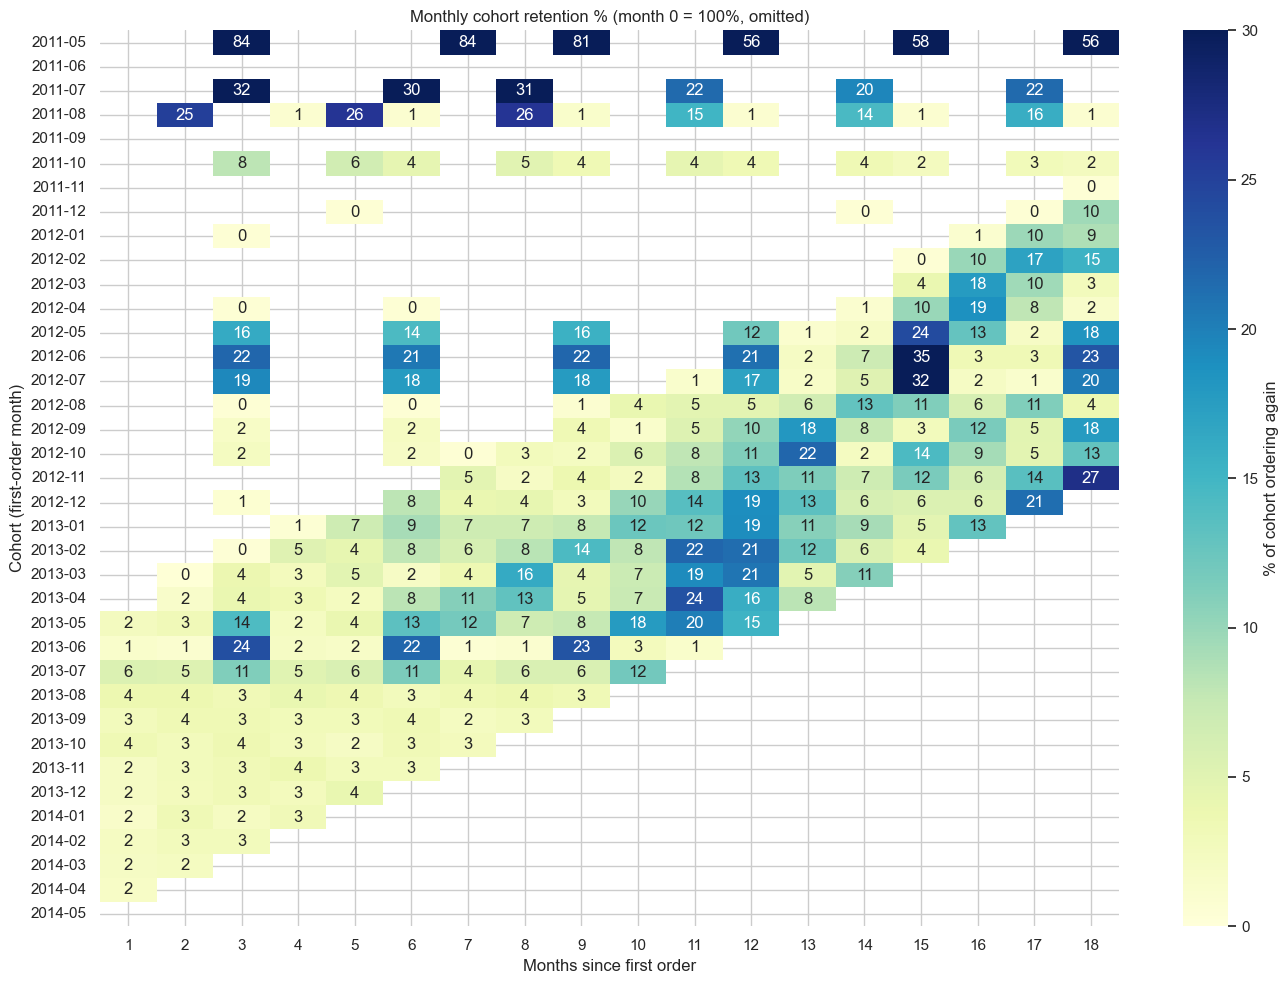

In [3]:
plt.figure(figsize=(14, 10))
sns.heatmap(retention.iloc[:, 1:19], annot=True, fmt='.0f', cmap='YlGnBu',
            vmin=0, vmax=30, cbar_kws={'label': '% of cohort ordering again'})
plt.title('Monthly cohort retention % (month 0 = 100%, omitted)')
plt.ylabel('Cohort (first-order month)'); plt.xlabel('Months since first order')
plt.tight_layout(); plt.show()

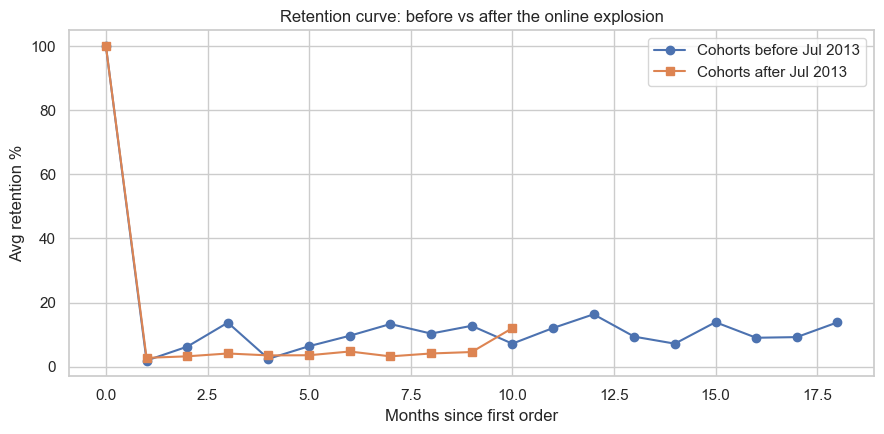

Avg month-12 retention, pre-Jul-2013 cohorts : 16.3 %
Avg month-3  retention, post-Jul-2013 cohorts: 4.1 %


In [4]:
# Average retention curve + before/after the July-2013 online explosion
r = retention.copy()
pre  = r[r.index <  '2013-07'].mean()
post = r[r.index >= '2013-07'].mean()
plt.figure(figsize=(9, 4.5))
plt.plot(pre.index[:19],  pre.values[:19],  marker='o', label='Cohorts before Jul 2013')
plt.plot(post.index[:12], post.values[:12], marker='s', label='Cohorts after Jul 2013')
plt.xlabel('Months since first order'); plt.ylabel('Avg retention %')
plt.title('Retention curve: before vs after the online explosion')
plt.legend(); plt.tight_layout(); plt.show()

print('Avg month-12 retention, pre-Jul-2013 cohorts :', round(pre.get(12, float('nan')), 1), '%')
print('Avg month-3  retention, post-Jul-2013 cohorts:', round(post.get(3, float('nan')), 1), '%')

In [5]:
# Write cohort summary back to SQL (for Power BI)
rows = []
for idx, val in pre.items():
    if pd.notna(val) and idx > 0:
        rows.append(('Pre-Jul-2013', int(idx), round(float(val), 1)))
for idx, val in post.items():
    if pd.notna(val) and idx > 0:
        rows.append(('Post-Jul-2013', int(idx), round(float(val), 1)))
cohort_summary = pd.DataFrame(rows, columns=['CohortGroup', 'MonthsSinceFirstOrder', 'RetentionPct'])

cur = cn.cursor()
cur.execute("IF OBJECT_ID('dbo.CohortRetentionSummary','U') IS NOT NULL DROP TABLE dbo.CohortRetentionSummary")
cur.execute("""CREATE TABLE dbo.CohortRetentionSummary (
    CohortGroup NVARCHAR(20), MonthsSinceFirstOrder INT, RetentionPct DECIMAL(5,1))""")
cur.fast_executemany = True
cur.executemany("INSERT INTO dbo.CohortRetentionSummary VALUES (?,?,?)",
                 cohort_summary.astype(object).values.tolist())
cn.commit()
print('rows written:', pd.read_sql('SELECT COUNT(*) n FROM dbo.CohortRetentionSummary', cn).n[0])

rows written: 45


## Part 2 — Market basket (subcategory level)
Product level is too granular (size/color variants), so we mine pairs of **subcategories**
inside the same order. Metrics:
- **Support** — % of orders containing the pair
- **Confidence** — P(B | A)
- **Lift** — how much more likely B is bought given A vs at random. Lift > 1 = real affinity.

In [6]:
lines = pd.read_sql("""
    SELECT d.SalesOrderID, sc.Name AS Subcategory
    FROM Sales.SalesOrderDetail d
    JOIN Production.Product p             ON d.ProductID = p.ProductID
    JOIN Production.ProductSubcategory sc ON p.ProductSubcategoryID = sc.ProductSubcategoryID
    GROUP BY d.SalesOrderID, sc.Name
""", cn)

n_orders = lines['SalesOrderID'].nunique()
baskets = lines.groupby('SalesOrderID')['Subcategory'].apply(frozenset)
baskets = baskets[baskets.str.len() > 1]
print(f'orders total: {n_orders:,} | multi-subcategory orders: {len(baskets):,}')

sub_count = lines.groupby('Subcategory')['SalesOrderID'].nunique()

pair_count = {}
for b in baskets:
    for pair in combinations(sorted(b), 2):
        pair_count[pair] = pair_count.get(pair, 0) + 1

rows = []
for (a, b), cnt in pair_count.items():
    support = cnt / n_orders
    lift = (cnt / n_orders) / ((sub_count[a] / n_orders) * (sub_count[b] / n_orders))
    conf_ab = cnt / sub_count[a]
    rows.append([a, b, cnt, round(100*support, 2), round(100*conf_ab, 1), round(lift, 2)])

pairs = (pd.DataFrame(rows, columns=['A', 'B', 'Orders', 'SupportPct', 'ConfAtoB_Pct', 'Lift'])
           .query('Orders >= 100')
           .sort_values('Lift', ascending=False))
print(pairs.head(15).to_string(index=False))

orders total: 31,465 | multi-subcategory orders: 18,276


              A           B  Orders  SupportPct  ConfAtoB_Pct   Lift
          Forks    Headsets     121        0.38          91.0 208.95
          Locks       Pumps     241        0.77          92.7 109.23
Bottom Brackets   Cranksets     223        0.71          89.9 108.40
Bottom Brackets      Chains     198        0.63          79.8 100.49
Bottom Brackets Derailleurs     220        0.70          88.7  98.63
         Chains Derailleurs     217        0.69          86.8  96.51
         Chains   Cranksets     200        0.64          80.0  96.44
Bottom Brackets      Brakes     222        0.71          89.5  95.48
      Cranksets Derailleurs     224        0.71          85.8  95.42
         Brakes      Chains     220        0.70          74.6  93.86
         Brakes Derailleurs     241        0.77          81.7  90.83
         Brakes   Cranksets     222        0.71          75.3  90.72
     Bib-Shorts       Pumps     252        0.80          63.6  74.99
     Bib-Shorts       Locks     24

In [7]:
# Write top basket pairs back to SQL (for Power BI)
top_pairs = pairs.head(15).rename(columns={
    'A': 'SubcategoryA', 'B': 'SubcategoryB', 'ConfAtoB_Pct': 'ConfidenceAtoB'})

cur = cn.cursor()
cur.execute("IF OBJECT_ID('dbo.BasketAffinity','U') IS NOT NULL DROP TABLE dbo.BasketAffinity")
cur.execute("""CREATE TABLE dbo.BasketAffinity (
    SubcategoryA NVARCHAR(50), SubcategoryB NVARCHAR(50), Orders INT,
    SupportPct DECIMAL(6,2), ConfidenceAtoB DECIMAL(6,1), Lift DECIMAL(10,2))""")
cur.fast_executemany = True
cur.executemany("INSERT INTO dbo.BasketAffinity VALUES (?,?,?,?,?,?)",
                 top_pairs[['SubcategoryA','SubcategoryB','Orders','SupportPct','ConfidenceAtoB','Lift']]
                    .astype(object).values.tolist())
cn.commit()
print('rows written:', pd.read_sql('SELECT COUNT(*) n FROM dbo.BasketAffinity', cn).n[0])

rows written: 15


orders containing a bike: 18,368
Subcategory
Helmets              22.9
Jerseys              16.0
Bottles and Cages    15.9
Tires and Tubes      12.4
Caps                 12.0
Gloves                8.3
Handlebars            5.0
Fenders               4.9
Shorts                4.7
Road Frames           4.5


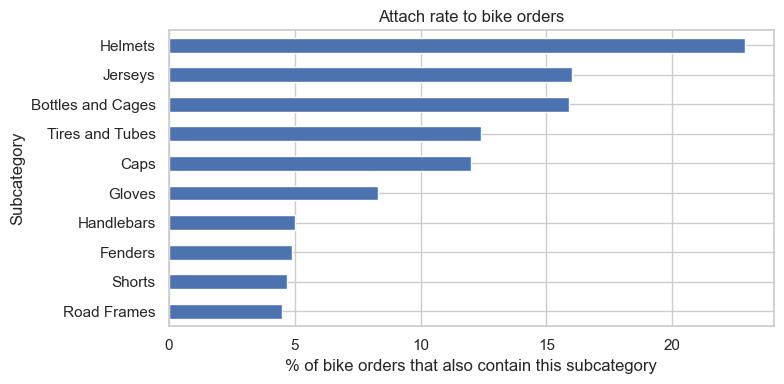

In [8]:
# What do BIKE buyers add to the basket? (attach-rate for the highest-value order type)
bike_orders = set(lines.loc[lines['Subcategory'].str.contains('Bikes'), 'SalesOrderID'])
attach = (lines[lines['SalesOrderID'].isin(bike_orders) &
                ~lines['Subcategory'].str.contains('Bikes')]
          .groupby('Subcategory')['SalesOrderID'].nunique()
          .sort_values(ascending=False))
attach_pct = (100 * attach / len(bike_orders)).round(1)
print(f'orders containing a bike: {len(bike_orders):,}')
print(attach_pct.head(10).to_string())

plt.figure(figsize=(8, 4))
attach_pct.head(10).plot(kind='barh', color='#4C72B0')
plt.gca().invert_yaxis()
plt.xlabel('% of bike orders that also contain this subcategory')
plt.title('Attach rate to bike orders')
plt.tight_layout(); plt.show()

## Business takeaways
*(see printed tables above)*
1. Retention curve shape confirms the 345-day repurchase window: a small bump around months 10-14.
2. Post-Jul-2013 cohorts (online accessory buyers) retain differently than early store-driven cohorts —
   this quantifies how much customer quality changed.
3. Top-lift subcategory pairs = ready-made bundle candidates.
4. Bike-order attach rates show which accessories to offer AT CHECKOUT on the highest-value orders.